<a href="https://colab.research.google.com/github/kxrrym03/Flower-Morphometrics-Analysis/blob/main/Flower_Morphometrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
from google.colab import files
uploaded = files.upload()

Saving extended_flower_morphometrics.csv to extended_flower_morphometrics.csv


In [3]:
df = pd.read_csv('extended_flower_morphometrics.csv')
df.shape

(200000, 9)

In [4]:
df.head()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,stem_thickness_mm,petal_density_pct,chlorophyll_index,native_altitude_m,species
0,4.317614,3.028292,6.092543,3.166156,5.063025,63.558150,55.913100,886.568622,Rose
1,5.531122,3.887679,5.497682,2.374855,4.656235,52.368783,26.383116,247.206553,Iris Versicolor
2,5.908407,2.576321,6.264473,1.785481,5.893707,36.056153,61.562376,1197.921681,Orchid
3,6.855284,2.764075,4.606390,1.175031,4.854951,55.623467,38.671083,940.401196,Iris Versicolor
4,5.412124,3.691987,1.800383,0.221225,2.528513,60.218904,34.674831,679.473136,Iris Setosa


In [5]:
df.tail()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,stem_thickness_mm,petal_density_pct,chlorophyll_index,native_altitude_m,species
199995,4.310318,3.203669,4.608296,3.181966,6.685197,74.660851,57.874758,669.014693,Rose
199996,5.441338,2.540579,3.065710,3.081896,6.412263,36.600376,49.377932,410.593633,Rose
199997,7.634411,2.717171,5.527709,0.544835,7.115064,64.974656,55.590180,1141.716023,Orchid
199998,5.840849,1.975244,8.855018,2.062708,6.483508,54.200146,28.485977,921.509666,Orchid
199999,6.177141,3.201139,4.291363,2.253710,4.440774,72.793139,34.516120,1143.161113,Orchid


In [6]:
df.isnull().sum()

,0
sepal_length_cm,0
sepal_width_cm,0
petal_length_cm,0
petal_width_cm,0
stem_thickness_mm,0
petal_density_pct,0
chlorophyll_index,0
native_altitude_m,0
species,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,stem_thickness_mm,petal_density_pct,chlorophyll_index,native_altitude_m
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,6.494801,3.701722,5.660341,2.339627,6.756894,53.202820,45.769422,568.676301
std,2.389844,1.219015,3.769632,1.761005,4.301134,13.891707,10.579623,277.763702
min,1.314396,-0.681257,-0.040491,-1.097662,-1.357669,-0.531327,2.766288,-562.840890
25%,4.976431,2.955377,3.371251,1.137561,3.772243,43.519517,38.443302,374.074507
50%,5.732968,3.406310,4.901882,2.118828,5.459812,52.465437,45.348677,552.110497
75%,6.973427,4.003575,6.466747,3.107515,7.910897,62.153948,52.640398,749.846888
max,18.797057,11.130567,24.222782,10.444469,28.019564,116.494596,98.869354,1954.432880


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   sepal_length_cm    200000 non-null  float64
 1   sepal_width_cm     200000 non-null  float64
 2   petal_length_cm    200000 non-null  float64
 3   petal_width_cm     200000 non-null  float64
 4   stem_thickness_mm  200000 non-null  float64
 5   petal_density_pct  200000 non-null  float64
 6   chlorophyll_index  200000 non-null  float64
 7   native_altitude_m  200000 non-null  float64
 8   species            200000 non-null  object 
dtypes: float64(8), object(1)
memory usage: 13.7+ MB


In [10]:
df.dtypes

,0
sepal_length_cm,float64
sepal_width_cm,float64
petal_length_cm,float64
petal_width_cm,float64
stem_thickness_mm,float64
petal_density_pct,float64
chlorophyll_index,float64
native_altitude_m,float64
species,object


In [11]:
df.columns

Index(['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm',
       'petal_width_cm', 'stem_thickness_mm', 'petal_density_pct',
       'chlorophyll_index', 'native_altitude_m', 'species'],
      dtype='object')

## Data Visualization

### Distribution of Numerical Features

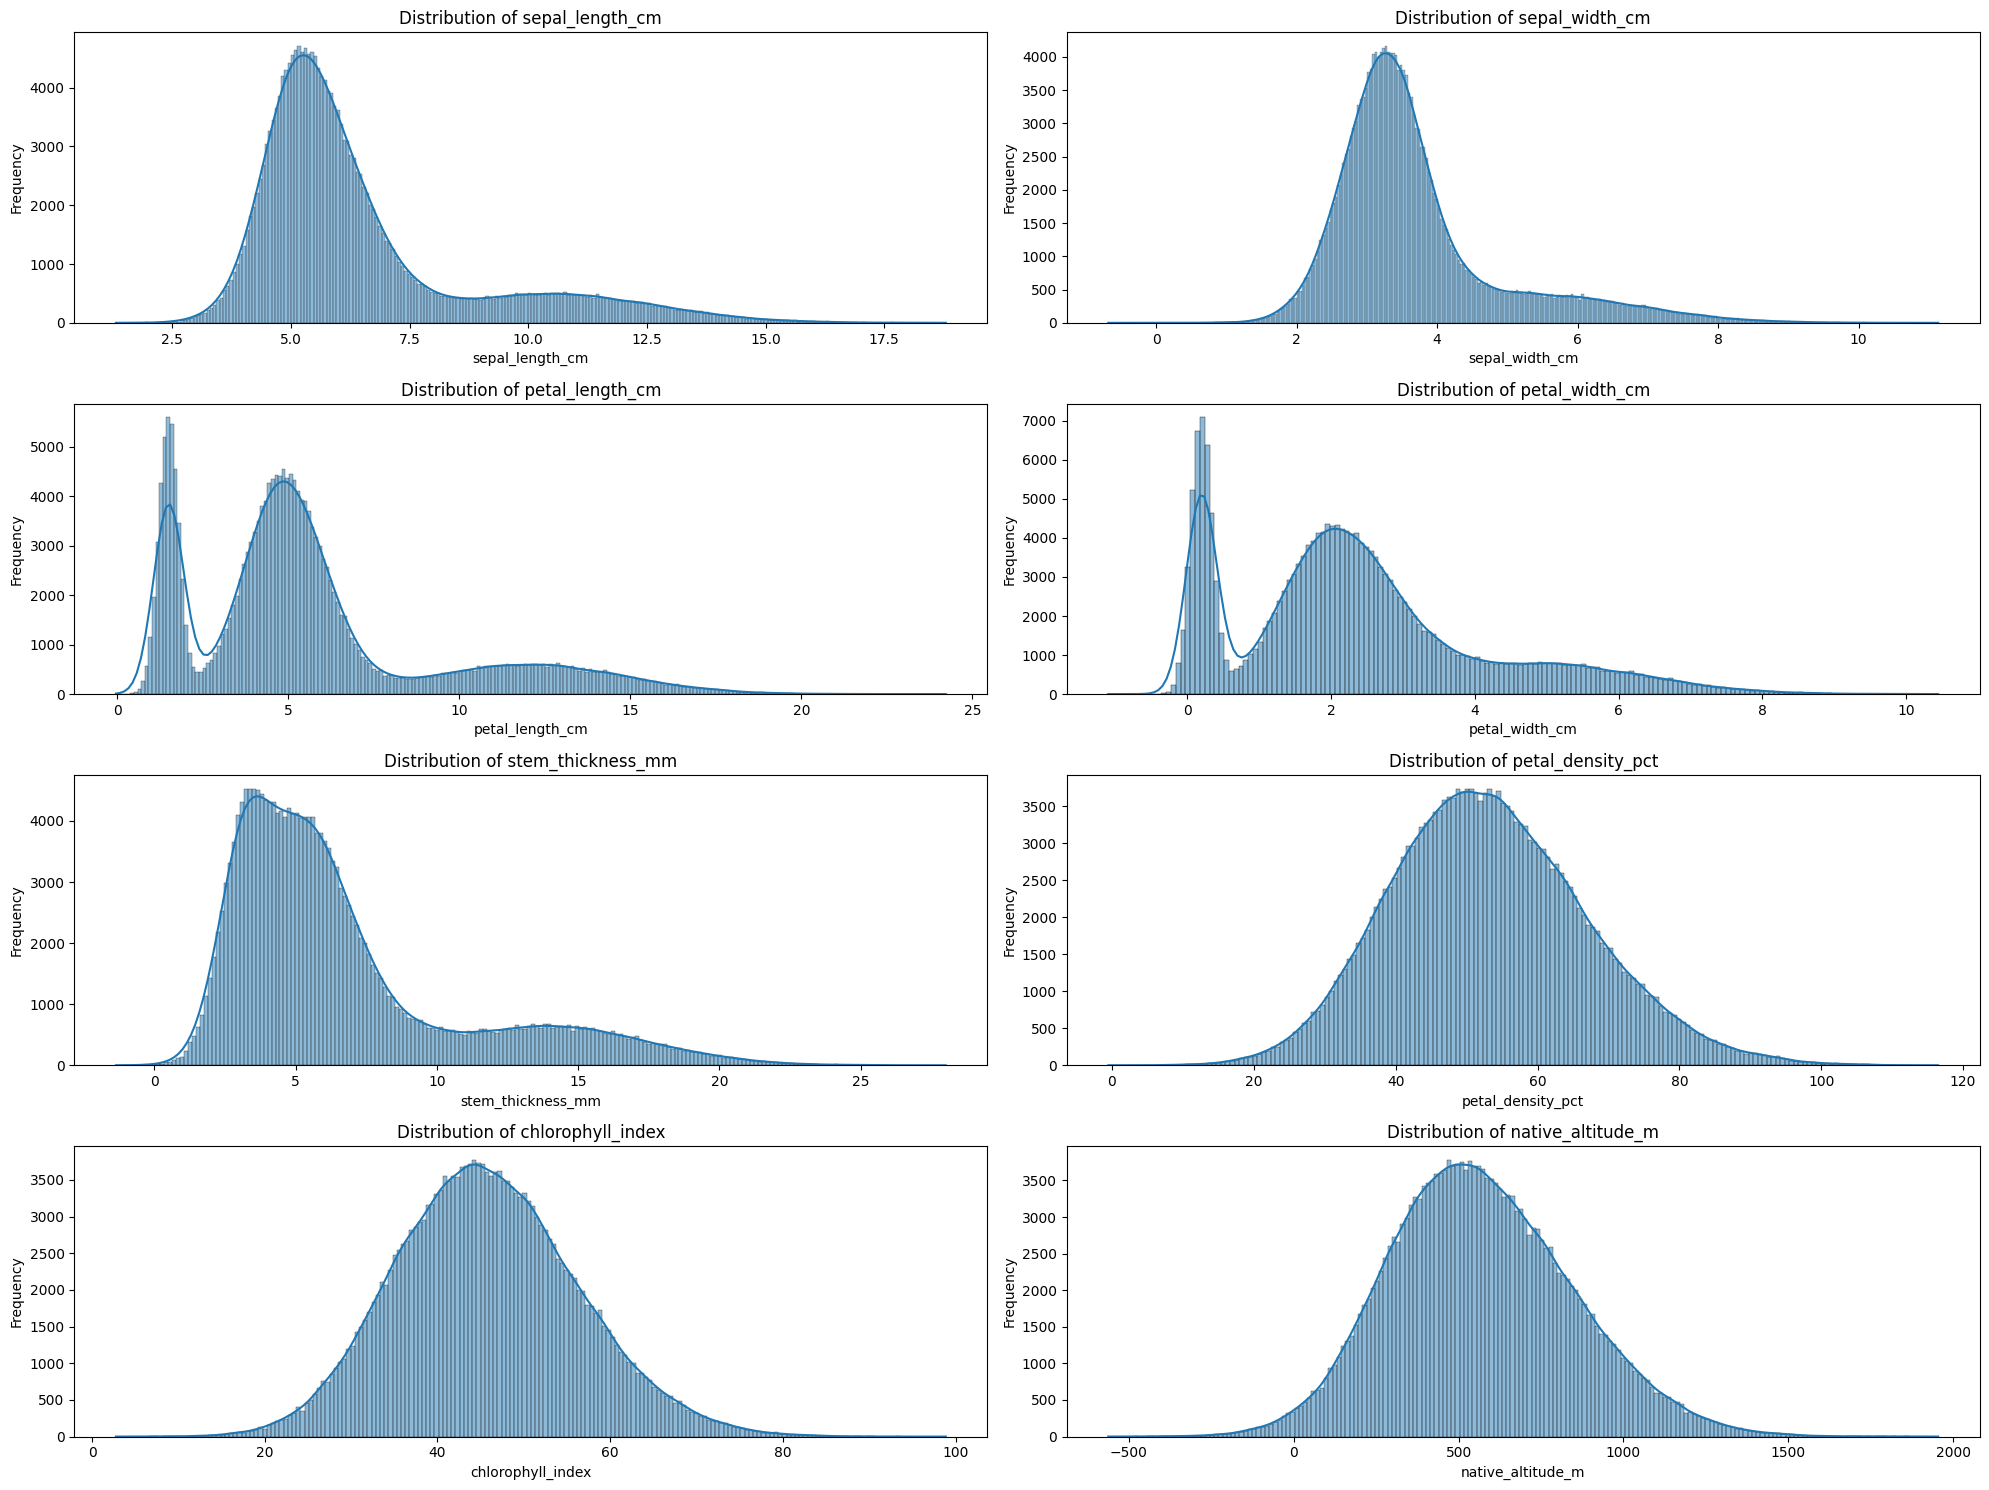

In [12]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 2, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

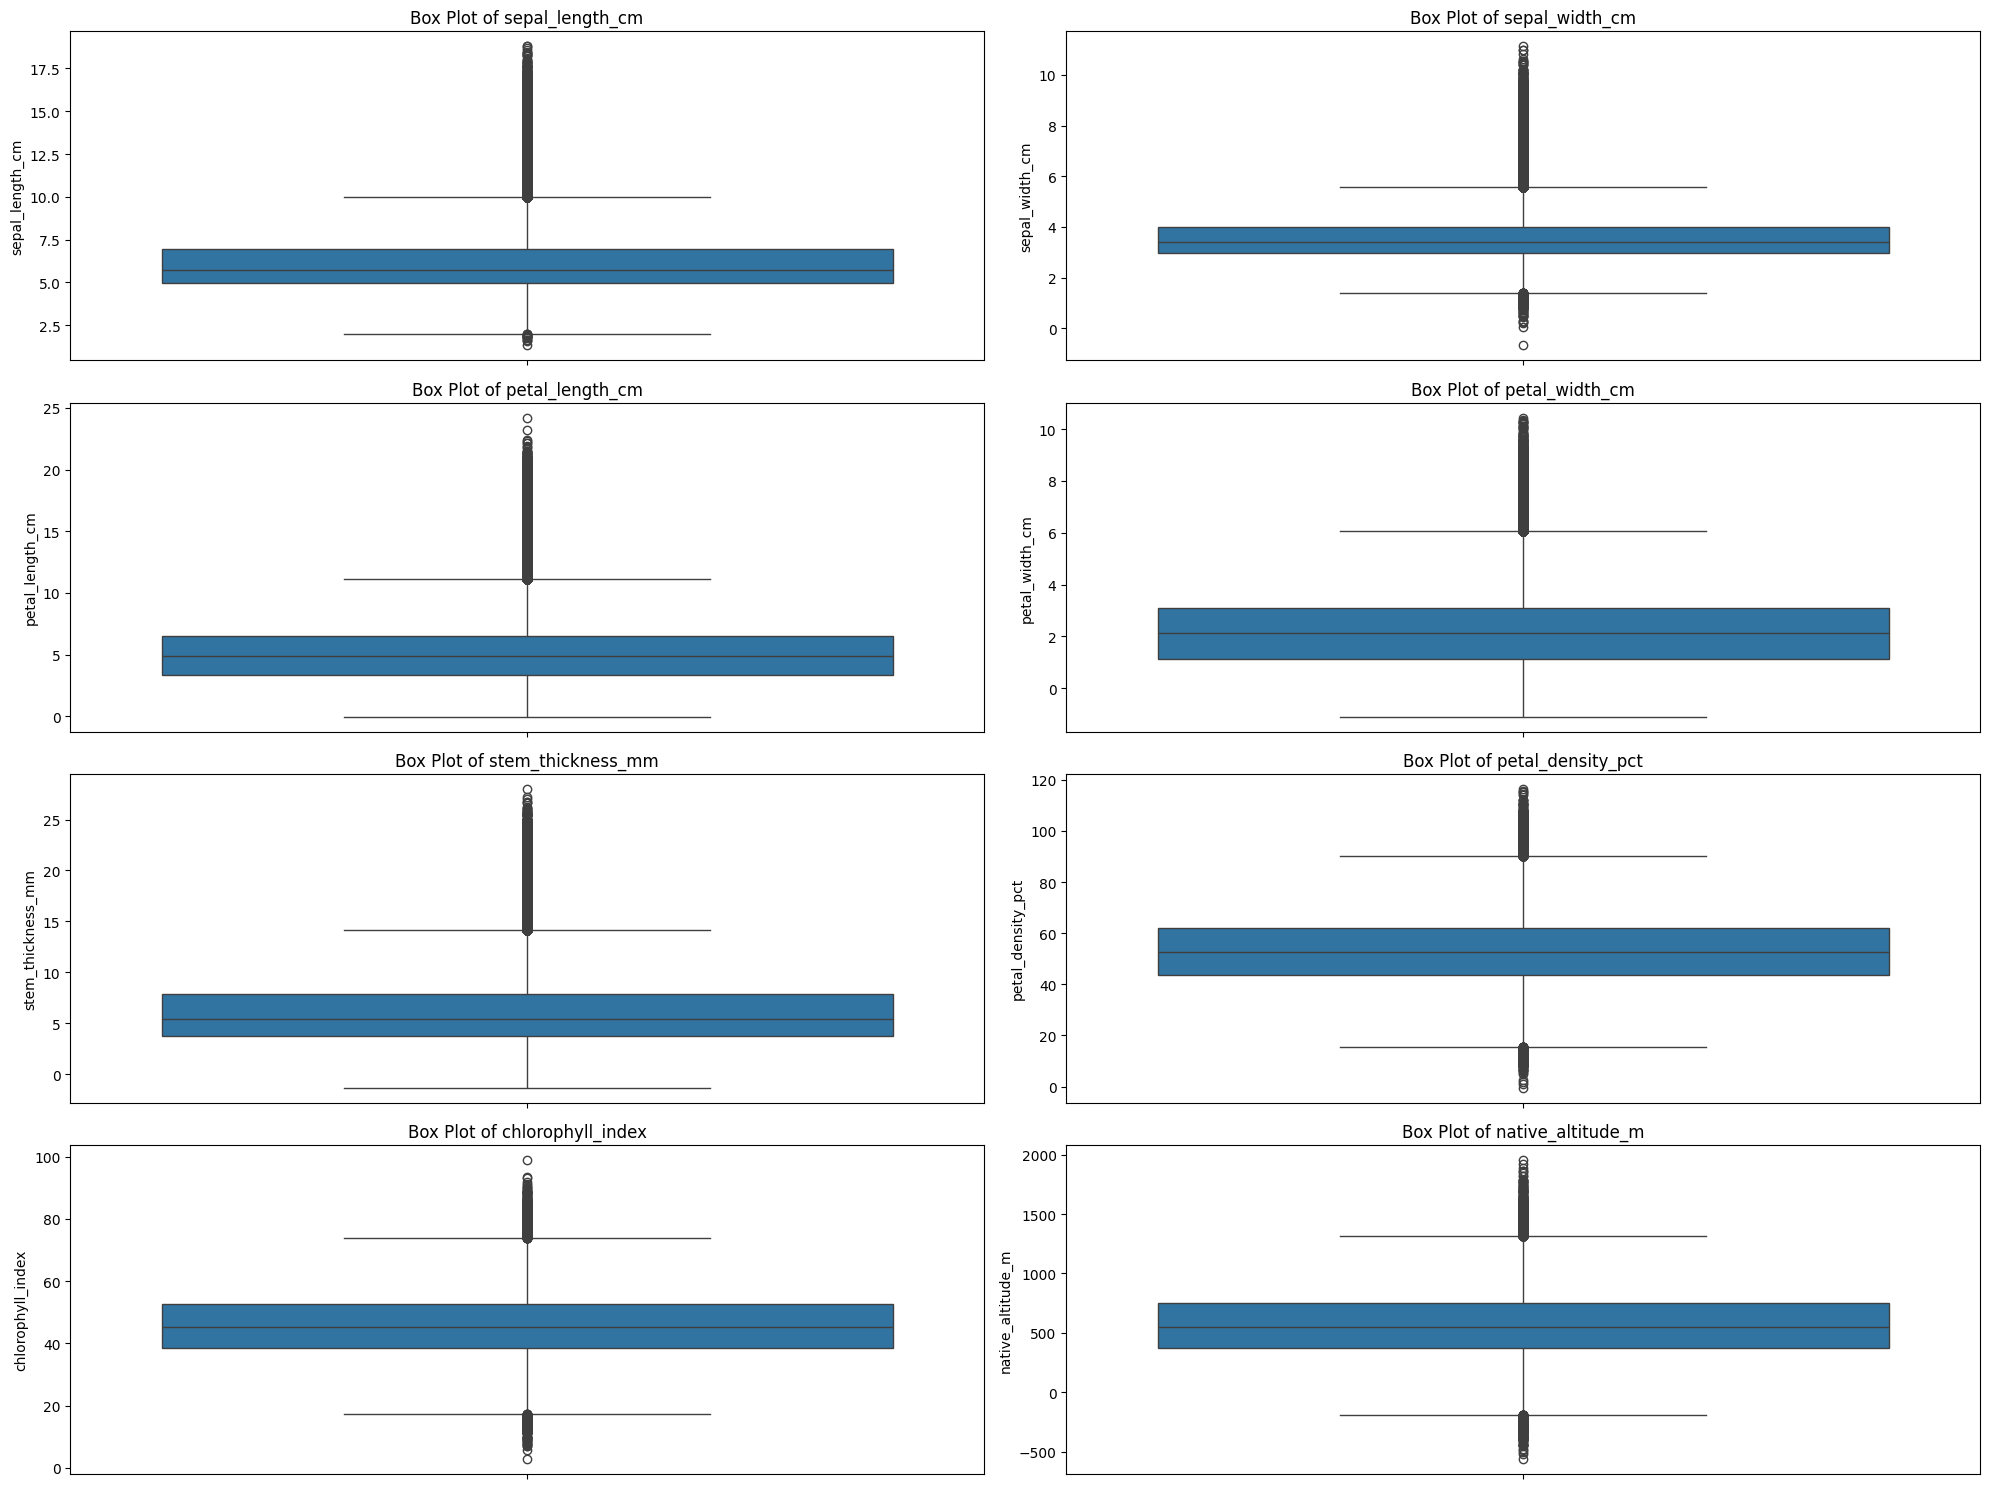

In [13]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 2, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Distribution of Species

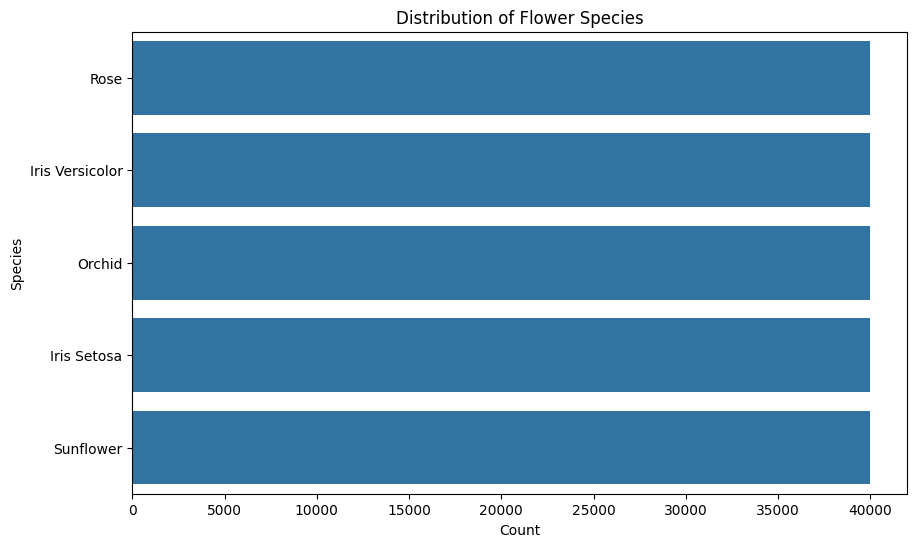

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(y='species', data=df, order=df['species'].value_counts().index)
plt.title('Distribution of Flower Species')
plt.xlabel('Count')
plt.ylabel('Species')
plt.show()

## Handling Negative Values

In [15]:
# List of columns identified with negative minimums
cols_with_negative_values = [
    'sepal_width_cm',
    'petal_length_cm',
    'petal_width_cm',
    'stem_thickness_mm',
    'petal_density_pct',
    'native_altitude_m'
]

# Replace negative values with NaN in these columns
for col in cols_with_negative_values:
    df[col] = df[col].apply(lambda x: np.nan if x < 0 else x)

# Verify the change by checking null values again
print('Number of nulls after replacing negative values:')
df.isnull().sum()

Number of nulls after replacing negative values:


,0
sepal_length_cm,0
sepal_width_cm,1
petal_length_cm,1
petal_width_cm,3695
stem_thickness_mm,48
petal_density_pct,1
chlorophyll_index,0
native_altitude_m,2616
species,0


### Impact of Negative Value Handling

In [16]:
df.describe()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,stem_thickness_mm,petal_density_pct,chlorophyll_index,native_altitude_m
count,200000.000000,199999.000000,199999.000000,196305.000000,199952.000000,199999.000000,200000.000000,197384.000000
mean,6.494801,3.701744,5.660370,2.385035,6.758611,53.203088,45.769422,577.358518
std,2.389844,1.218978,3.769620,1.745798,4.300218,13.891222,10.579623,268.932261
min,1.314396,0.033121,0.153141,0.000007,0.002380,0.861140,2.766288,0.146279
25%,4.976431,2.955386,3.371269,1.232898,3.773393,43.519593,38.443302,381.940153
50%,5.732968,3.406311,4.901884,2.147371,5.460522,52.465467,45.348677,556.666985
75%,6.973427,4.003582,6.466753,3.136710,7.912047,62.154018,52.640398,752.892642
max,18.797057,11.130567,24.222782,10.444469,28.019564,116.494596,98.869354,1954.432880


## Imputing Missing Values with Median

In [17]:
# List of columns with NaNs to impute
cols_to_impute = [
    'sepal_width_cm',
    'petal_length_cm',
    'petal_width_cm',
    'stem_thickness_mm',
    'petal_density_pct',
    'native_altitude_m'
]

# Impute NaNs with the median of each column
for col in cols_to_impute:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)

print('Number of nulls after median imputation:')
df.isnull().sum()

Number of nulls after median imputation:


,0
sepal_length_cm,0
sepal_width_cm,0
petal_length_cm,0
petal_width_cm,0
stem_thickness_mm,0
petal_density_pct,0
chlorophyll_index,0
native_altitude_m,0
species,0


### Dataset Statistics After Imputation

In [18]:
df.describe()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,stem_thickness_mm,petal_density_pct,chlorophyll_index,native_altitude_m
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,6.494801,3.701743,5.660366,2.380644,6.758299,53.203085,45.769422,577.087873
std,2.389844,1.218975,3.769611,1.729892,4.299749,13.891188,10.579623,267.177989
min,1.314396,0.033121,0.153141,0.000007,0.002380,0.861140,2.766288,0.146279
25%,4.976431,2.955386,3.371278,1.261487,3.773674,43.519629,38.443302,384.618158
50%,5.732968,3.406311,4.901884,2.147371,5.460522,52.465467,45.348677,556.666985
75%,6.973427,4.003575,6.466747,3.107515,7.910897,62.153948,52.640398,749.846888
max,18.797057,11.130567,24.222782,10.444469,28.019564,116.494596,98.869354,1954.432880


## Handling Outliers using IQR Method

In [19]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers: replace values outside the bounds with the bounds themselves
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print("Outliers handled for numerical columns using IQR capping.")

Outliers handled for numerical columns using IQR capping.


### Dataset Statistics After Outlier Handling

In [20]:
df.describe()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,stem_thickness_mm,petal_density_pct,chlorophyll_index,native_altitude_m
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,6.263254,3.597999,5.335686,2.334808,6.490816,53.165313,45.748909,576.333478
std,1.831740,0.951279,3.048957,1.613577,3.649150,13.757328,10.495222,264.856210
min,1.980935,1.383104,0.153141,0.000007,0.002380,15.568150,17.147659,0.146279
25%,4.976431,2.955386,3.371278,1.261487,3.773674,43.519629,38.443302,384.618158
50%,5.732968,3.406311,4.901884,2.147371,5.460522,52.465467,45.348677,556.666985
75%,6.973427,4.003575,6.466747,3.107515,7.910897,62.153948,52.640398,749.846888
max,9.968923,5.575858,11.109950,5.876558,14.116732,90.105426,73.936042,1297.689983


### Visualizing Distributions After Outlier Handling

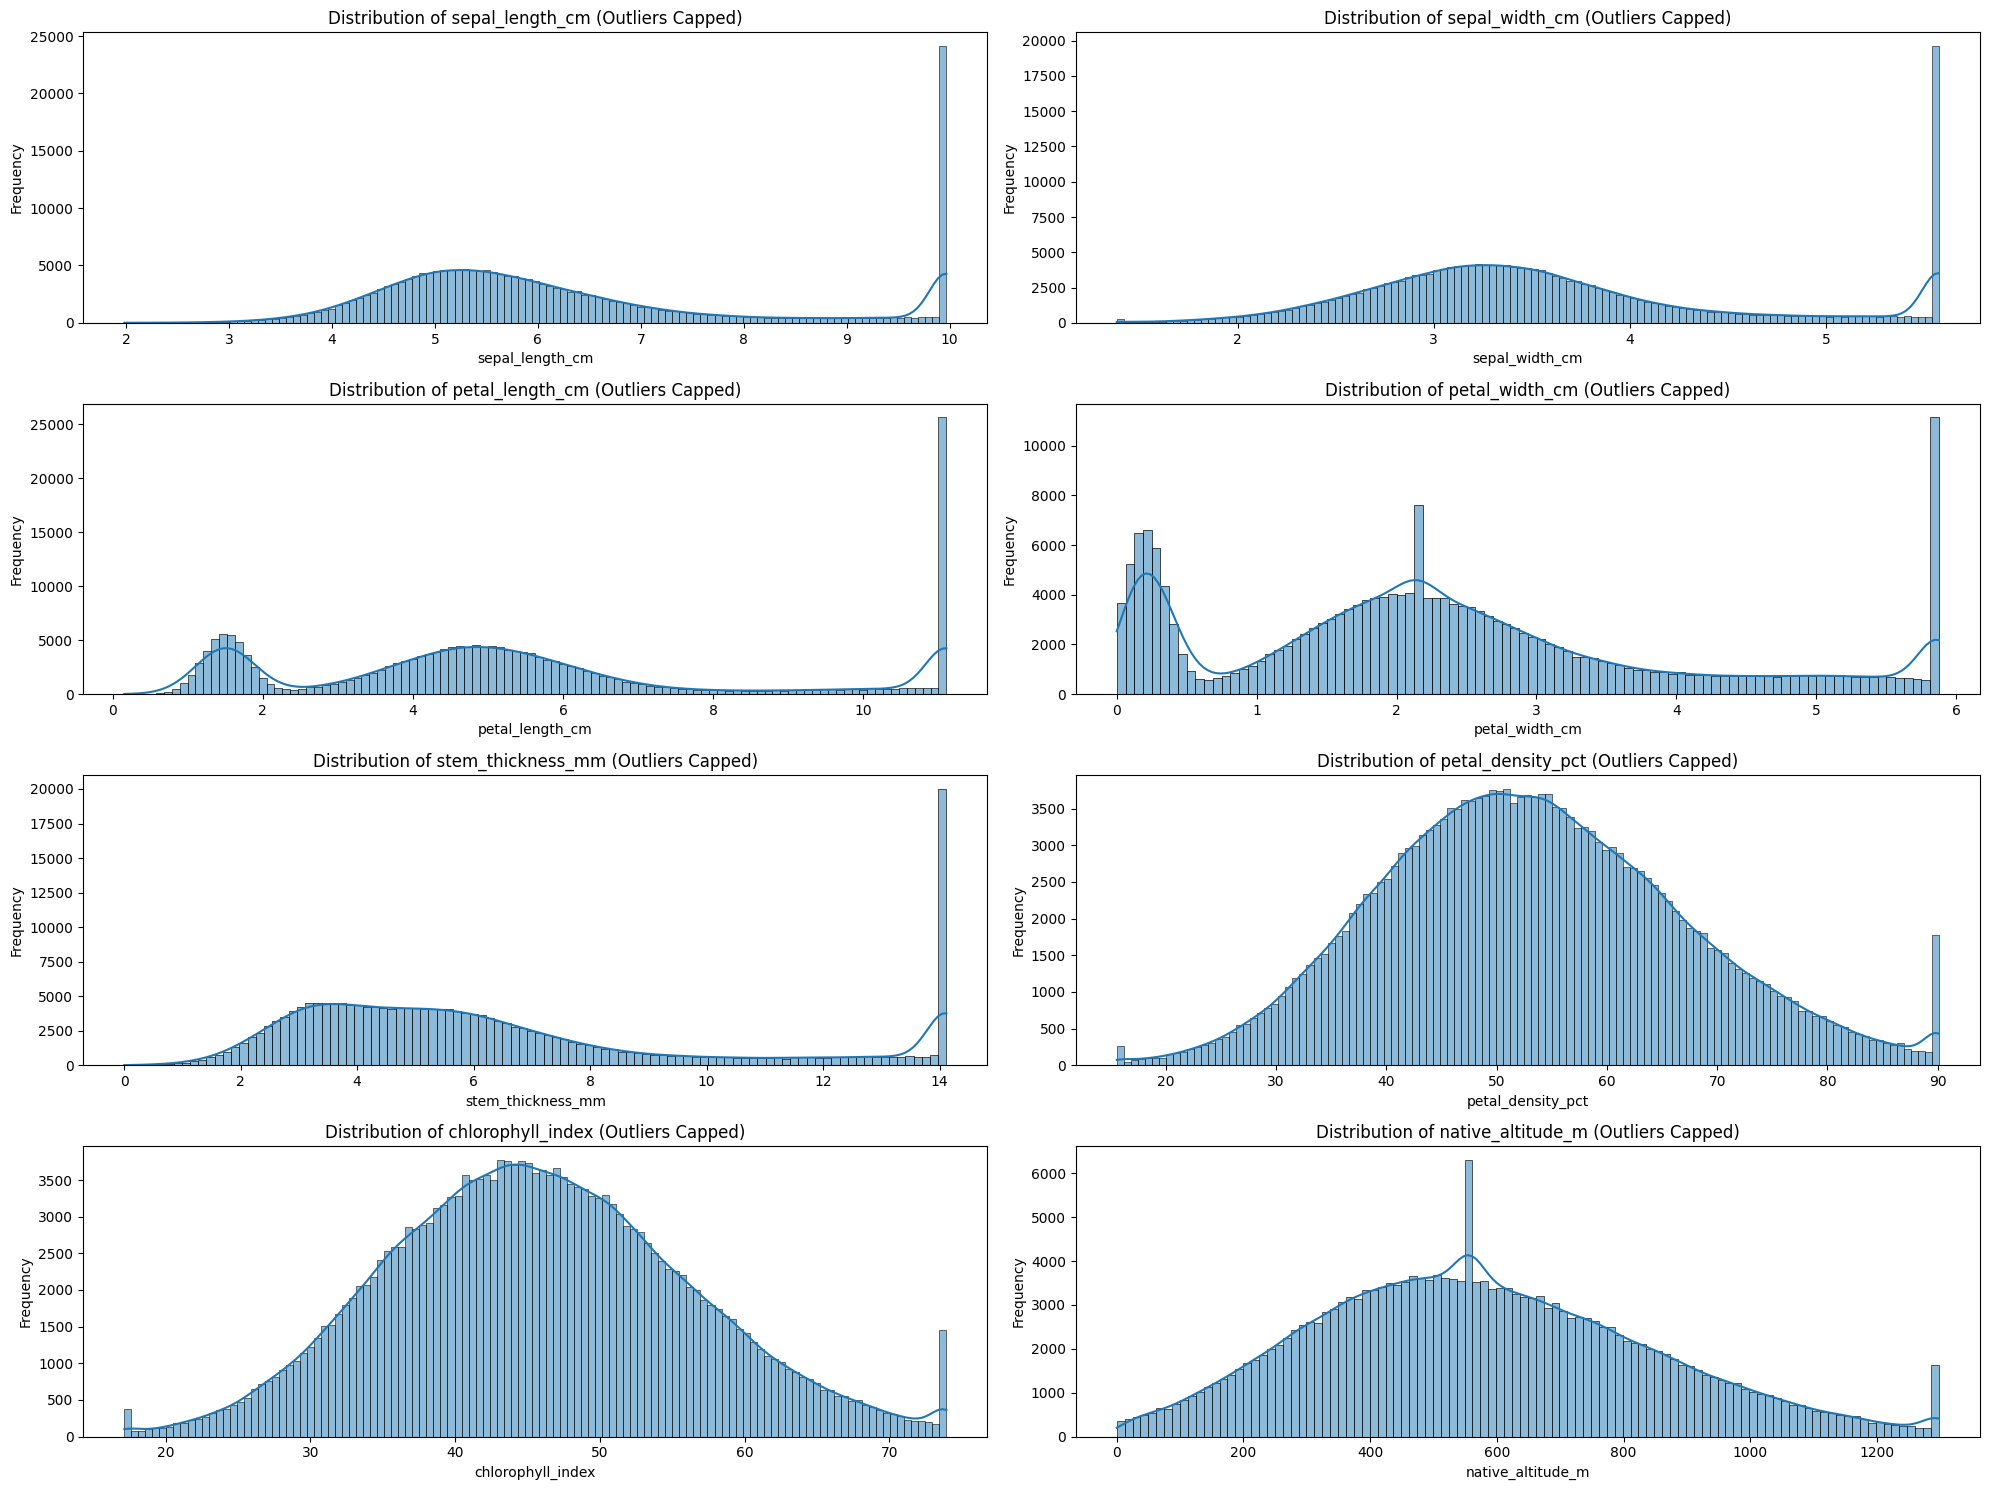

In [21]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 2, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col} (Outliers Capped)')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

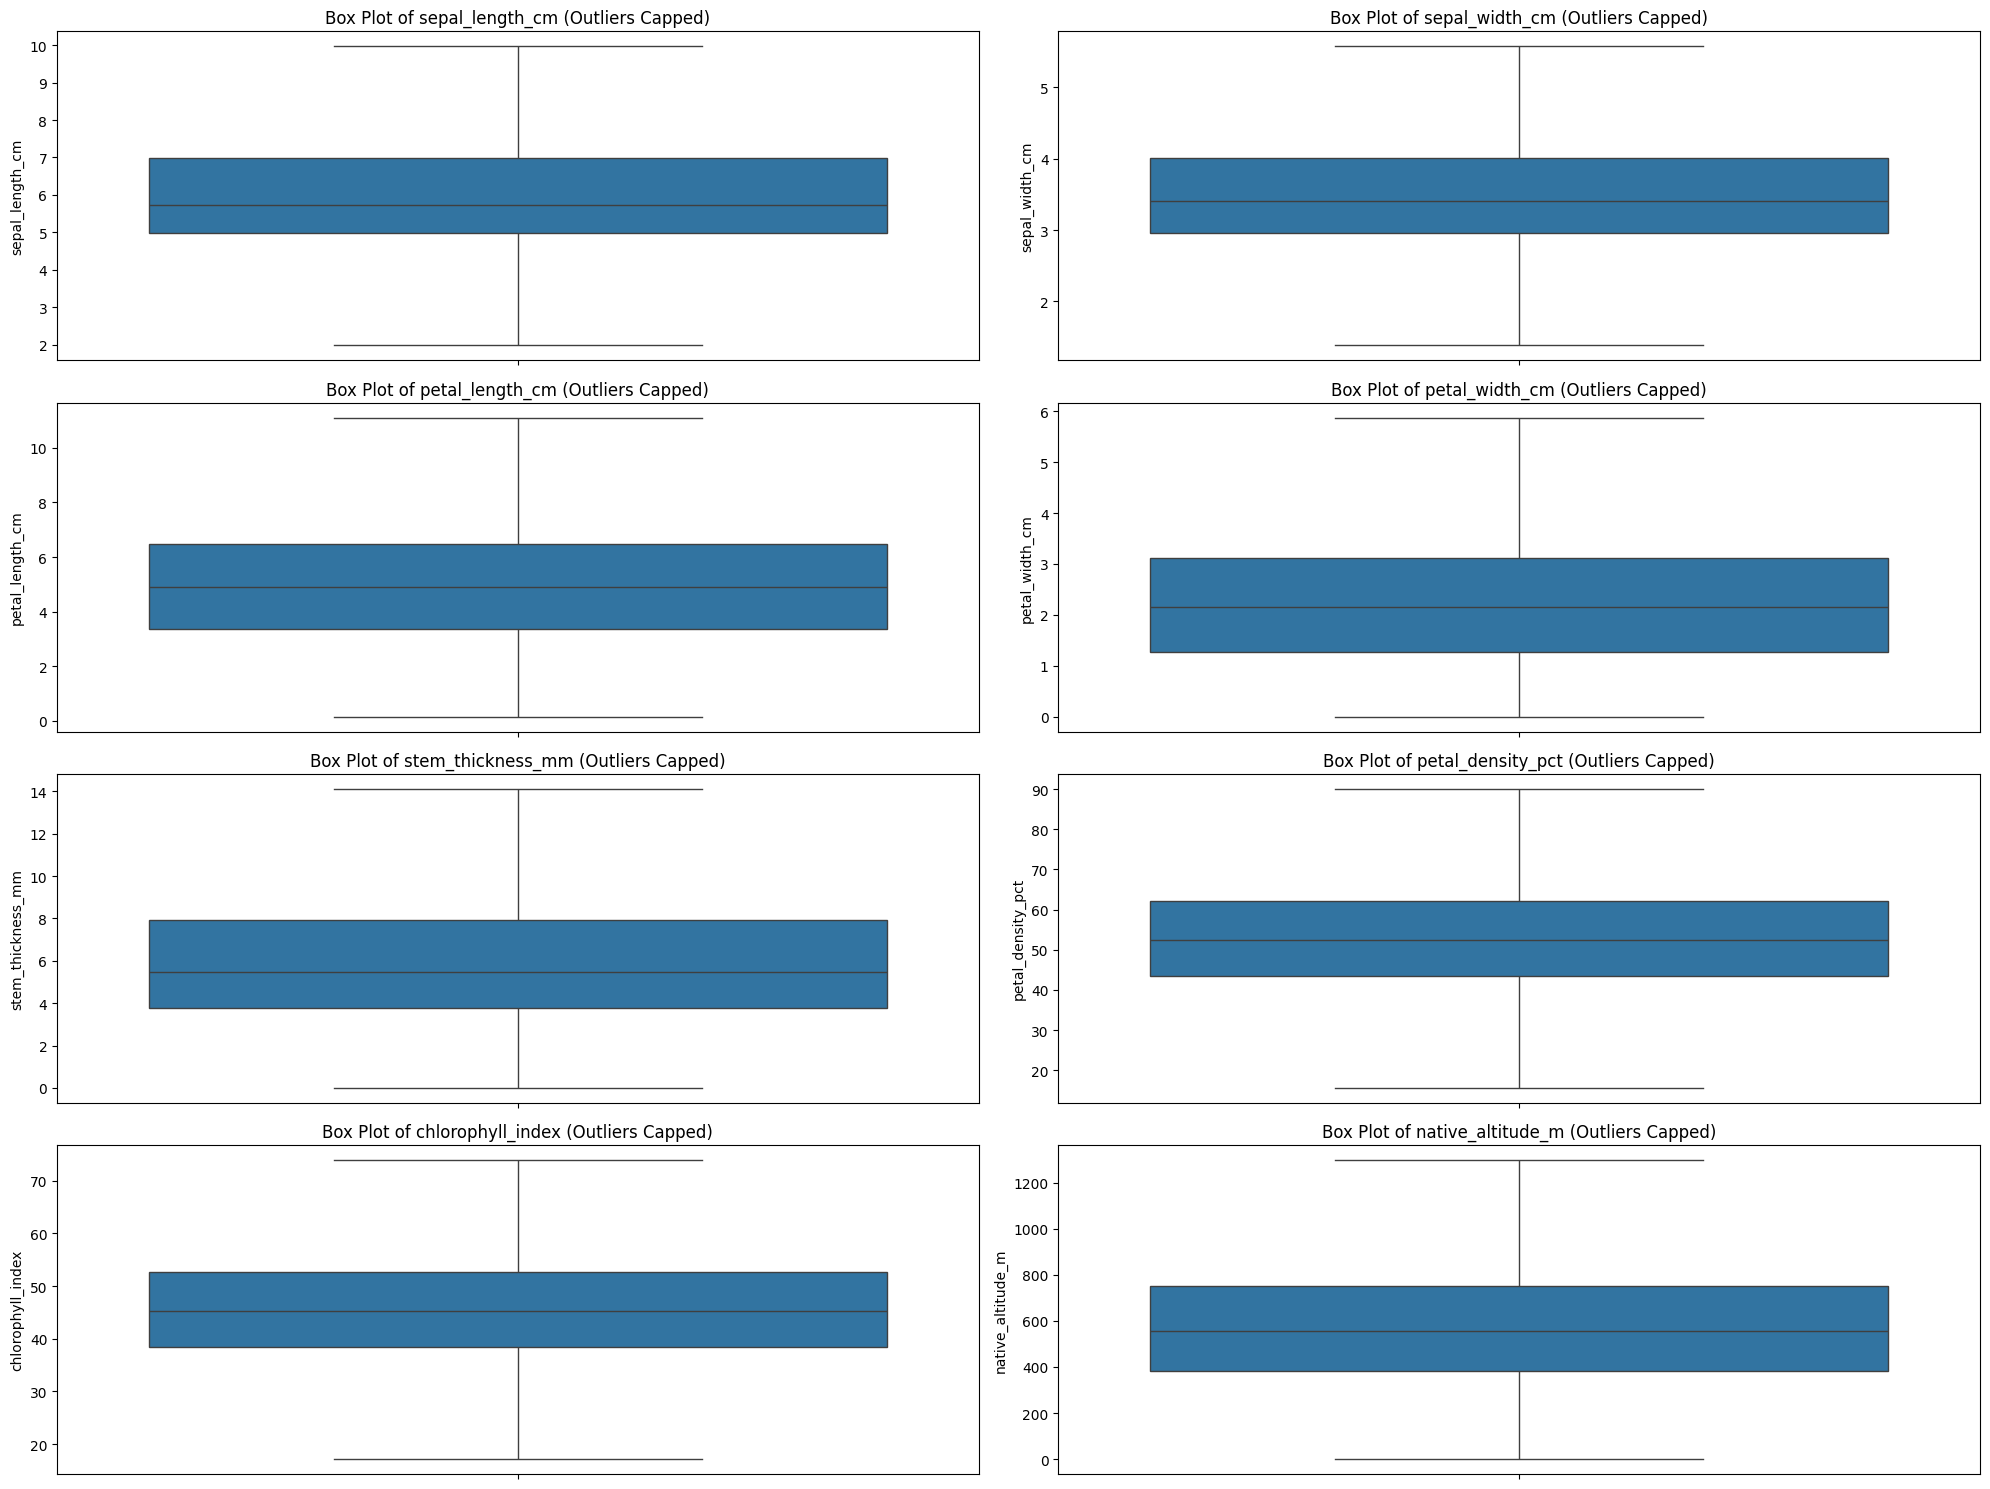

In [22]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 2, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col} (Outliers Capped)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

## Encoding Categorical Variables

In [23]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to the 'species' column
df['species_encoded'] = le.fit_transform(df['species'])

print("Original species column dropped, 'species_encoded' column added.")

# Display the first few rows with the new encoded column
print("\nDataFrame head after encoding:")
print(df.head())

# Display value counts of the encoded species
print("\nValue counts of 'species_encoded':")
print(df['species_encoded'].value_counts())

Original species column dropped, 'species_encoded' column added.

DataFrame head after encoding:
   sepal_length_cm  sepal_width_cm  petal_length_cm  petal_width_cm  \
0         4.317614        3.028292         6.092543        3.166156   
1         5.531122        3.887679         5.497682        2.374855   
2         5.908407        2.576321         6.264473        1.785481   
3         6.855284        2.764075         4.606390        1.175031   
4         5.412124        3.691987         1.800383        0.221225   

   stem_thickness_mm  petal_density_pct  chlorophyll_index  native_altitude_m  \
0           5.063025          63.558150          55.913100         886.568622   
1           4.656235          52.368783          26.383116         247.206553   
2           5.893707          36.056153          61.562376        1197.921681   
3           4.854951          55.623467          38.671083         940.401196   
4           2.528513          60.218904          34.674831         679.

## Final Data Overview

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   sepal_length_cm    200000 non-null  float64
 1   sepal_width_cm     200000 non-null  float64
 2   petal_length_cm    200000 non-null  float64
 3   petal_width_cm     200000 non-null  float64
 4   stem_thickness_mm  200000 non-null  float64
 5   petal_density_pct  200000 non-null  float64
 6   chlorophyll_index  200000 non-null  float64
 7   native_altitude_m  200000 non-null  float64
 8   species            200000 non-null  object 
 9   species_encoded    200000 non-null  int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 15.3+ MB


In [25]:
df.describe()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,stem_thickness_mm,petal_density_pct,chlorophyll_index,native_altitude_m,species_encoded
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,6.263254,3.597999,5.335686,2.334808,6.490816,53.165313,45.748909,576.333478,2.000000
std,1.831740,0.951279,3.048957,1.613577,3.649150,13.757328,10.495222,264.856210,1.414217
min,1.980935,1.383104,0.153141,0.000007,0.002380,15.568150,17.147659,0.146279,0.000000
25%,4.976431,2.955386,3.371278,1.261487,3.773674,43.519629,38.443302,384.618158,1.000000
50%,5.732968,3.406311,4.901884,2.147371,5.460522,52.465467,45.348677,556.666985,2.000000
75%,6.973427,4.003575,6.466747,3.107515,7.910897,62.153948,52.640398,749.846888,3.000000
max,9.968923,5.575858,11.109950,5.876558,14.116732,90.105426,73.936042,1297.689983,4.000000


## Preparing Data for Modeling

### Dropping Original Species Column

In [26]:
# Drop the original 'species' column
df_model = df.drop('species', axis=1)

print("Original 'species' column dropped. New DataFrame head:")
print(df_model.head())

Original 'species' column dropped. New DataFrame head:
   sepal_length_cm  sepal_width_cm  petal_length_cm  petal_width_cm  \
0         4.317614        3.028292         6.092543        3.166156   
1         5.531122        3.887679         5.497682        2.374855   
2         5.908407        2.576321         6.264473        1.785481   
3         6.855284        2.764075         4.606390        1.175031   
4         5.412124        3.691987         1.800383        0.221225   

   stem_thickness_mm  petal_density_pct  chlorophyll_index  native_altitude_m  \
0           5.063025          63.558150          55.913100         886.568622   
1           4.656235          52.368783          26.383116         247.206553   
2           5.893707          36.056153          61.562376        1197.921681   
3           4.854951          55.623467          38.671083         940.401196   
4           2.528513          60.218904          34.674831         679.473136   

   species_encoded  
0         

### Splitting Data into Features (X) and Target (y)

In [27]:
# Define features (X) and target (y)
X = df_model.drop('species_encoded', axis=1)
y = df_model['species_encoded']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)
print("\nFeatures (X) head:")
print(X.head())

Shape of features (X): (200000, 8)
Shape of target (y): (200000,)

Features (X) head:
   sepal_length_cm  sepal_width_cm  petal_length_cm  petal_width_cm  \
0         4.317614        3.028292         6.092543        3.166156   
1         5.531122        3.887679         5.497682        2.374855   
2         5.908407        2.576321         6.264473        1.785481   
3         6.855284        2.764075         4.606390        1.175031   
4         5.412124        3.691987         1.800383        0.221225   

   stem_thickness_mm  petal_density_pct  chlorophyll_index  native_altitude_m  
0           5.063025          63.558150          55.913100         886.568622  
1           4.656235          52.368783          26.383116         247.206553  
2           5.893707          36.056153          61.562376        1197.921681  
3           4.854951          55.623467          38.671083         940.401196  
4           2.528513          60.218904          34.674831         679.473136  


### Splitting Data into Training and Testing Sets

In [28]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (160000, 8)
X_test shape: (40000, 8)
y_train shape: (160000,)
y_test shape: (40000,)


## Feature Scaling

In [29]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler.")

# Display the first few rows of the scaled training data
print("\nScaled X_train (first 5 rows):")
print(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())

# Display the first few rows of the scaled testing data
print("\nScaled X_test (first 5 rows):")
print(pd.DataFrame(X_test_scaled, columns=X_test.columns).head())

Features scaled using StandardScaler.

Scaled X_train (first 5 rows):
   sepal_length_cm  sepal_width_cm  petal_length_cm  petal_width_cm  \
0         1.229222        2.079127         1.894496        2.191883   
1        -0.166972       -0.571592        -0.200989        0.896201   
2        -0.456391       -0.363652         0.203286        0.294969   
3         0.093016       -0.690426        -0.554829       -0.627151   
4        -0.768038       -0.863208        -0.326976        0.627325   

   stem_thickness_mm  petal_density_pct  chlorophyll_index  native_altitude_m  
0           1.329909           0.856052           1.609217          -0.313991  
1          -0.189478           0.966893          -0.686828           0.217426  
2          -0.746554           1.802567          -0.284536          -0.940454  
3           0.108762           0.274421          -0.819506           1.519591  
4          -0.418668           0.052155          -0.102190           1.979692  

Scaled X_test (first 5

### Data Ready for Model Training

## Model Training: RandomForestClassifier

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize the RandomForestClassifier
# Using a fixed random_state for reproducibility
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
print("Training RandomForestClassifier...")
model.fit(X_train_scaled, y_train)
print("Model training complete.")

Training RandomForestClassifier...
Model training complete.


## Model Evaluation

In [31]:
# Make predictions on the scaled test data
y_pred = model.predict(X_test_scaled)

# Evaluate the model
print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy Score:
0.81775

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8000
           1       0.63      0.65      0.64      8000
           2       0.66      0.65      0.65      8000
           3       0.81      0.79      0.80      8000
           4       1.00      1.00      1.00      8000

    accuracy                           0.82     40000
   macro avg       0.82      0.82      0.82     40000
weighted avg       0.82      0.82      0.82     40000


Confusion Matrix:
[[7998    2    0    0    0]
 [   4 5220 1947  829    0]
 [   1 2200 5160  638    1]
 [   0  919  740 6338    3]
 [   0    0    0    6 7994]]


### Visualizing the Confusion Matrix

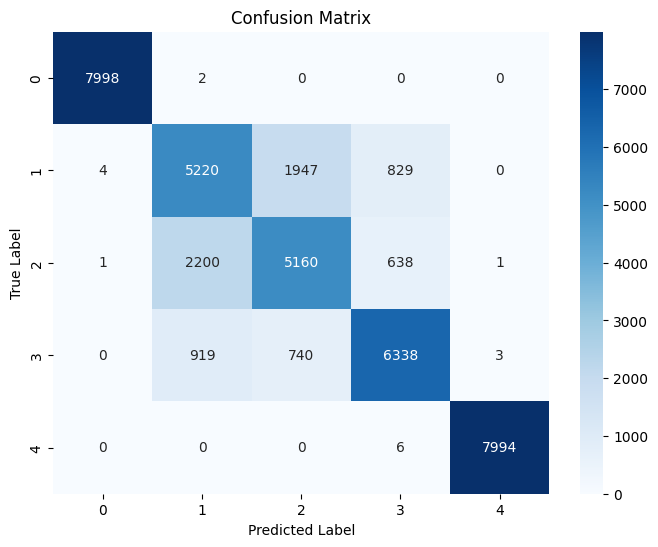

In [32]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [33]:
from sklearn.metrics import accuracy_score

# Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

Accuracy Score: 0.8177


In [34]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8000
           1       0.63      0.65      0.64      8000
           2       0.66      0.65      0.65      8000
           3       0.81      0.79      0.80      8000
           4       1.00      1.00      1.00      8000

    accuracy                           0.82     40000
   macro avg       0.82      0.82      0.82     40000
weighted avg       0.82      0.82      0.82     40000



## Model Training: XGBClassifier

In [35]:
from xgboost import XGBClassifier

# Initialize the XGBClassifier
# Using a fixed random_state for reproducibility
xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss')

# Train the model
print("Training XGBClassifier...")
xgb_model.fit(X_train_scaled, y_train)
print("XGBClassifier training complete.")

Training XGBClassifier...
XGBClassifier training complete.


## Model Evaluation: XGBClassifier

In [36]:
# Make predictions on the scaled test data using the XGBoost model
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Evaluate the XGBoost model
print("\nAccuracy Score (XGBoost):")
print(accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix (XGBoost):")
print(confusion_matrix(y_test, y_pred_xgb))


Accuracy Score (XGBoost):
0.82065

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8000
           1       0.63      0.67      0.65      8000
           2       0.67      0.64      0.65      8000
           3       0.81      0.79      0.80      8000
           4       1.00      1.00      1.00      8000

    accuracy                           0.82     40000
   macro avg       0.82      0.82      0.82     40000
weighted avg       0.82      0.82      0.82     40000


Confusion Matrix (XGBoost):
[[8000    0    0    0    0]
 [   5 5369 1820  806    0]
 [   1 2215 5121  660    3]
 [   0  936  717 6347    0]
 [   0    0    1   10 7989]]


### Visualizing the Confusion Matrix (XGBClassifier)

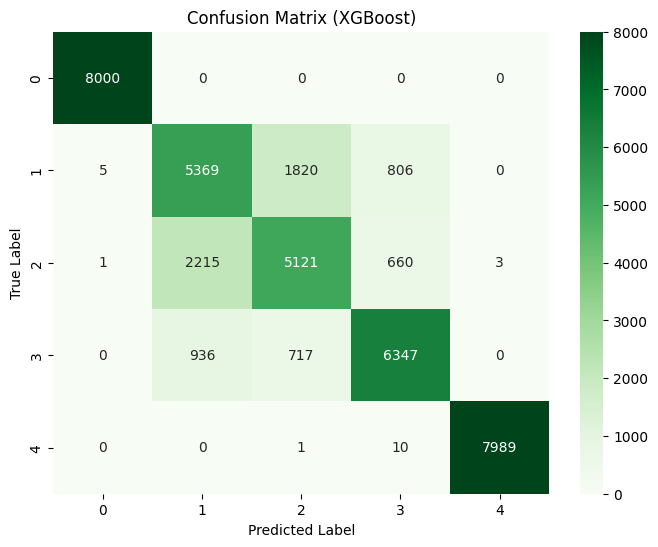

In [37]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix (XGBoost)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()